In [1]:
import pandas as pd
import csv

# Re-read the file correctly
# The original error 'ParserError: Error tokenizing data. C error: EOF inside string'
# indicates a malformed CSV, likely with unescaped quotes or newlines within fields.
# Using the 'python' engine is more robust for such cases.
# 'on_bad_lines='warn'' will issue warnings for problematic lines rather than failing.
df = pd.read_csv('WELFake_Dataset.csv', engine='python', on_bad_lines='warn')

# Drop the 'Unnamed: 0' index column if it exists
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# Combine title and text into 'content' like you did before
df['content'] = df['title'].fillna('') + " " + df['text'].fillna('')

# Keep only what you need
df = df[['content', 'label']]

# Ensure 'label' column is numeric and handle potential non-numeric entries
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

/tmp/ipykernel_803/604459497.py:9: ParserWarning: Skipping line 329: field larger than field limit (131072)

  df = pd.read_csv('WELFake_Dataset.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_803/604459497.py:9: ParserWarning: Skipping line 873: unexpected end of data

  df = pd.read_csv('WELFake_Dataset.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_803/604459497.py:9: ParserWarning: Skipping line 335: Expected 4 fields in line 335, saw 6

  df = pd.read_csv('WELFake_Dataset.csv', engine='python', on_bad_lines='warn')


In [2]:
print(df.head())
print(df.columns)

                                             content  label
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...      1
1     Did they post their votes for Hillary already?      1
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...      1
3  Bobby Jindal, raised Hindu, uses story of Chri...      0
4  SATAN 2: Russia unvelis an image of its terrif...      1
Index(['content', 'label'], dtype='object')


In [3]:
import re
import string

def preprocess_text(text):
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(f'[{re.escape(string.digits)}]', '', text)
    return text.strip()

# Now run your function
df['processed_content'] = df['content'].apply(preprocess_text)

# Check the result
df[['content', 'processed_content']].head()

,content,processed_content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...
1,Did they post their votes for Hillary already?,did they post their votes for hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obama’s attorney general says mos...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",bobby jindal raised hindu uses story of christ...
4,SATAN 2: Russia unvelis an image of its terrif...,satan russia unvelis an image of its terrifyi...


In [4]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(f'[{re.escape(string.digits)}]', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 853 entries, 0 to 868
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   content            853 non-null    object
 1   label              853 non-null    int64 
 2   processed_content  853 non-null    object
dtypes: int64(1), object(2)
memory usage: 26.7+ KB


,label
count,853.000000
mean,0.539273
std,0.498748
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [6]:
df['label'].value_counts()

,count
label,
1,460
0,393


<Axes: >

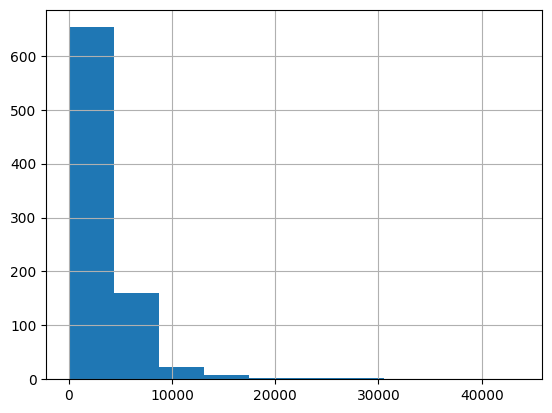

In [7]:
df['length'] = df['processed_content'].apply(len)

df['length'].hist()

In [8]:
from collections import Counter

all_words = " ".join(df['processed_content']).split()
Counter(all_words).most_common(20)

[('the', 27492),
 ('to', 13866),
 ('of', 12275),
 ('and', 11066),
 ('a', 10848),
 ('in', 9437),
 ('that', 6291),
 ('is', 4607),
 ('for', 4589),
 ('on', 4473),
 ('it', 3170),
 ('he', 3119),
 ('with', 3096),
 ('was', 3026),
 ('said', 2908),
 ('as', 2894),
 ('by', 2617),
 ('his', 2323),
 ('be', 2243),
 ('s', 2223)]

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

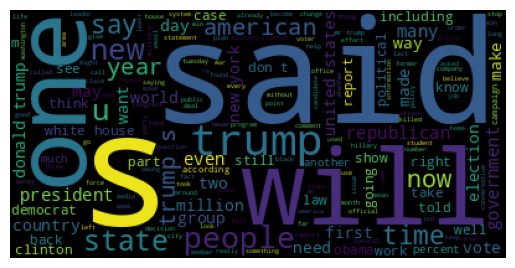

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud().generate(" ".join(df['processed_content']))
plt.imshow(wordcloud)
plt.axis("off")

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['processed_content'])
y = df['label']

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Ensure processed_content exists
if 'processed_content' not in df.columns:
    df['processed_content'] = df['content'].apply(preprocess_text)

# 1. Features and Target
X = df['processed_content']
y = df['label']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Vectorize
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# 4. Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# 5. Predict
y_pred = model.predict(X_test_tfidf)

# 6. Results table
label_map = {0: 'Fake', 1: 'Real'}
results_df = pd.DataFrame({
    'Actual_Text_Snippet': X_test.str[:100] + "...",
    'True_Label':      [label_map[i] for i in y_test],
    'Predicted_Label': [label_map[i] for i in y_pred]
})

# 7. Display
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\n--- Predicted vs. True Labels ---")
print(results_df.head(15).to_string(index=False))

Model Accuracy: 88.30%

--- Predicted vs. True Labels ---
                                                                                     Actual_Text_Snippet True_Label Predicted_Label
 gop lawmaker to trump stop acting like a ‘fragile’ snowflake over town hall protests angry constitue...       Real            Real
 will barack obama delay or suspend the election if hillary is forced out by the new fbi email invest...       Real            Real
 one hilarious tweet perfectly sums up how irrelevant cnn has become nunes dropped a bombshell that o...       Real            Real
 trump says strong europe is important for us washington reuters  president donald trump said on thur...       Fake            Fake
 trump considering ’explosive’ executive order on unfair trade the trump administration is working on...       Fake            Fake
 us carries out first strikes against islamic state in somalia washington reuters  the united states ...       Fake            Fake
 trump’s take on c

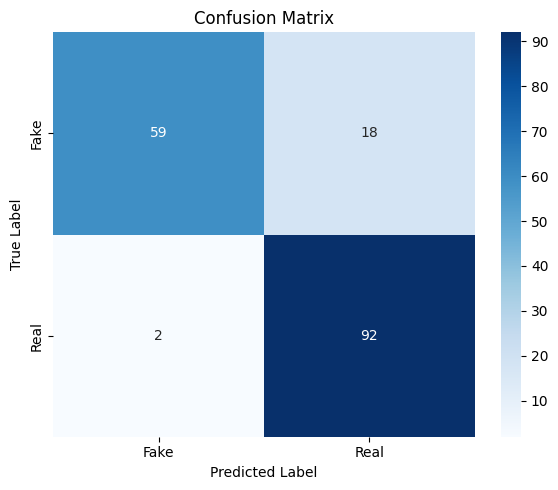

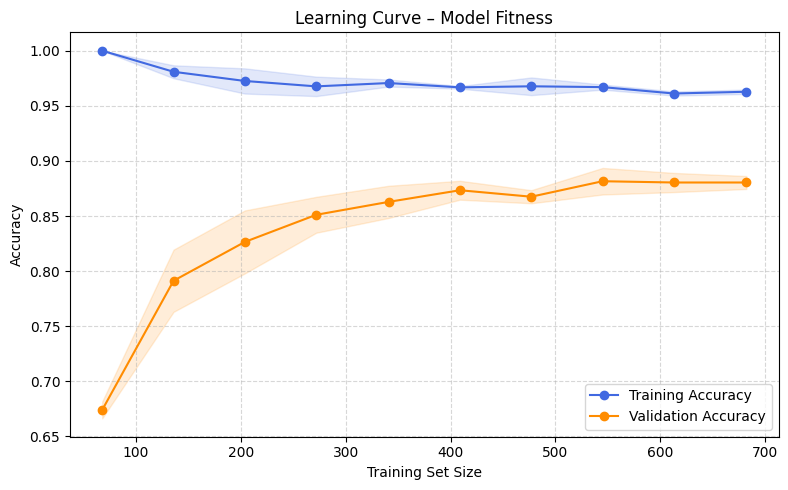

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import learning_curve
import numpy as np

# ── 1. Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── 2. Learning Curve (Model Fitness) ────────────────────────────────
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf',   LogisticRegression(max_iter=1000))
])

train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue',  label='Training Accuracy')
plt.plot(train_sizes, val_mean,   'o-', color='darkorange', label='Validation Accuracy')

plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.15, color='royalblue')
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.15, color='darkorange')

plt.title('Learning Curve – Model Fitness')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150)
plt.show()


The confusion matrix indicates that the model correctly classifies most of the news articles, with relatively fewer misclassifications. The learning curve shows that training and validation accuracy converge, suggesting that the model generalizes well and does not suffer from severe overfitting.

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.77      0.86        77
           1       0.84      0.98      0.90        94

    accuracy                           0.88       171
   macro avg       0.90      0.87      0.88       171
weighted avg       0.90      0.88      0.88       171



In [14]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8830409356725146


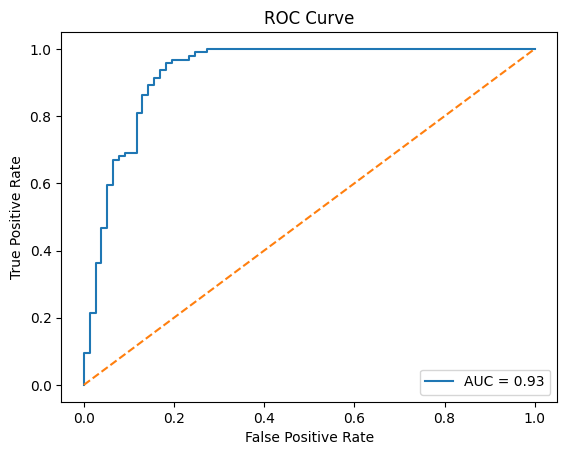

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Ensure processed_content exists (from cell FgQq9bJHmhBs)
# Assuming df is available in the kernel state
if 'processed_content' not in df.columns:
    import re
    import string
    def preprocess_text(text):
        text = text.lower()
        text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
        text = re.sub(f'[{re.escape(string.digits)}]', '', text)
        return text.strip()
    df['processed_content'] = df['content'].apply(preprocess_text)

# Define X and y (from cell FgQq9bJHmhBs)
X = df['processed_content']
y = df['label']

# Split the data into training and testing sets (from cell FgQq9bJHmhBs)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the pipeline (from cell 2tKarjv7mkzY)
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf',   LogisticRegression(max_iter=1000))
])

# Fit the pipeline to the training data
pipeline.fit(X_train, y_train)

# Now predict probabilities for the ROC curve
y_prob = pipeline.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [16]:
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coefficients = pipeline.named_steps['clf'].coef_[0]

# Top words for REAL
top_real = sorted(zip(coefficients, feature_names), reverse=True)[:10]

# Top words for FAKE
top_fake = sorted(zip(coefficients, feature_names))[:10]

print("Top words indicating REAL news:")
for coef, word in top_real:
    print(word, coef)

print("\nTop words indicating FAKE news:")
for coef, word in top_fake:
    print(word, coef)

Top words indicating REAL news:
is 1.5504644004323578
hillary 1.4634888486176856
video 1.4490843919003151
this 1.3089394005097255
you 1.1915976521514051
they 1.1401064873098752
just 0.9840237812657139
that 0.9083044350204793
obama 0.8965585165066348
what 0.8800372904302131

Top words indicating FAKE news:
said -4.11333088801357
reuters -2.283007852415252
mr -2.1681374853982422
on -1.7793135135371718
in -1.7650160413469316
the -1.0648951507873938
senate -1.0123627948193055
washington -0.9833228541967013
ms -0.8802619197147964
state -0.8567135761414277


In [17]:
df['content'].iloc[0]

'LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizers is called  Sunshine.  She has a radio blog show hosted from Texas called,  Sunshine s F***ing Opinion Radio Show. A snapshot of her #FYF911 @LOLatWhiteFear Twitter page at 9:53 p.m. shows that she was urging supporters to  Call now!! #fyf911 tonight we continue to dismantle the illusion of white Below is a SNAPSHOT Twitter Radio Call Invite   #FYF911The radio show aired at 10:00 p.m. eastern standard time.During the show, callers clearly call for  lynching  and  killing  of white people.A 2:3

In [18]:
sample = df['content'].iloc[0]

print("Text:", sample)
print("Prediction:", pipeline.predict([sample]))

Text: LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizers is called  Sunshine.  She has a radio blog show hosted from Texas called,  Sunshine s F***ing Opinion Radio Show. A snapshot of her #FYF911 @LOLatWhiteFear Twitter page at 9:53 p.m. shows that she was urging supporters to  Call now!! #fyf911 tonight we continue to dismantle the illusion of white Below is a SNAPSHOT Twitter Radio Call Invite   #FYF911The radio show aired at 10:00 p.m. eastern standard time.During the show, callers clearly call for  lynching  and  killing  of white people.

In [19]:
import joblib

joblib.dump(pipeline, "logistic_model.pkl")

['logistic_model.pkl']

In [20]:
from google.colab import files
files.download("logistic_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>